<a href="https://colab.research.google.com/github/Shah4l/deep-learning-projects/blob/main/Modeling_binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout


In [ ]:
df=pd.read_csv('/content/Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
le=LabelEncoder()
df['Geography']=le.fit_transform(df['Geography'])
df['Gender']=le.fit_transform(df['Gender'])


In [ ]:
df=df.drop(['RowNumber','Surname'],axis=1)

In [ ]:
df

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,1,1,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
x=df.drop(['Exited'],axis=1)
y=df['Exited']

In [ ]:
x

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15634602,619,0,0,42,2,0.00,1,1,1,101348.88
1,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58
2,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57
3,15701354,699,0,0,39,1,0.00,2,0,0,93826.63
4,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,0,1,39,5,0.00,2,1,0,96270.64
9996,15569892,516,0,1,35,10,57369.61,1,1,1,101699.77
9997,15584532,709,0,0,36,7,0.00,1,0,1,42085.58
9998,15682355,772,1,1,42,3,75075.31,2,1,0,92888.52


In [ ]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
x_train

array([[-1.24645641,  0.35649971, -0.9055496 , ...,  0.64920267,
         0.97481699,  1.36766974],
       [ 1.05381124, -0.20389777,  0.30164867, ...,  0.64920267,
         0.97481699,  1.6612541 ],
       [ 0.3664786 , -0.96147213,  1.50884694, ...,  0.64920267,
        -1.02583358, -0.25280688],
       ...,
       [-1.6259648 ,  0.86500853, -0.9055496 , ..., -1.54035103,
        -1.02583358, -0.1427649 ],
       [ 1.62852321,  0.15932282, -0.9055496 , ...,  0.64920267,
        -1.02583358, -0.05082558],
       [ 0.21718071,  0.47065475,  0.30164867, ...,  0.64920267,
         0.97481699, -0.81456811]])

In [ ]:
x_test

array([[-0.04416715, -0.57749609,  0.30164867, ..., -1.54035103,
        -1.02583358, -1.01960511],
       [ 0.64443214, -0.29729735, -0.9055496 , ...,  0.64920267,
         0.97481699,  0.79888291],
       [ 0.43240018, -0.52560743,  1.50884694, ...,  0.64920267,
        -1.02583358, -0.72797953],
       ...,
       [ 0.77960199,  0.81311987, -0.9055496 , ...,  0.64920267,
        -1.02583358, -1.16591585],
       [-0.02204946,  0.41876609, -0.9055496 , ...,  0.64920267,
        -1.02583358, -0.41163463],
       [-0.5433811 , -0.24540869,  0.30164867, ...,  0.64920267,
         0.97481699,  0.12593183]])

In [ ]:
model = Sequential()
model.add(Dense(units=11, activation='relu'))
model.add(Dense(units=7, activation='relu'))
model.add(Dense(units=6, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
callbacks = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20
)

In [ ]:
training_info=model.fit(x_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=callbacks)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8062 - loss: 0.4381 - val_accuracy: 0.8061 - val_loss: 0.4416
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8107 - loss: 0.4317 - val_accuracy: 0.8228 - val_loss: 0.4314
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8295 - loss: 0.4064 - val_accuracy: 0.8262 - val_loss: 0.4214
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8344 - loss: 0.4059 - val_accuracy: 0.8330 - val_loss: 0.4114
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8501 - loss: 0.3778 - val_accuracy: 0.8353 - val_loss: 0.4015
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8481 - loss: 0.3799 - val_accuracy: 0.8402 - val_loss: 0.3902
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8562 - loss: 0.3656 - val_accuracy: 0.8417 - val_loss: 0.3810
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8514 - loss: 0.3627 - 

In [ ]:
training_info.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

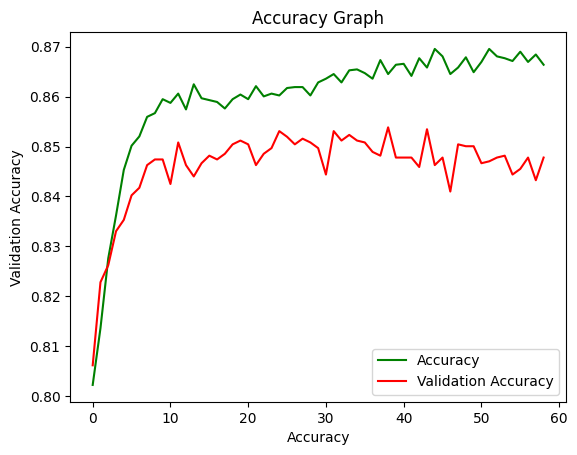

In [ ]:
plt.plot(training_info.history['accuracy'],color='green',label='Accuracy')
plt.plot(training_info.history['val_accuracy'],color='red',label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Accuracy')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

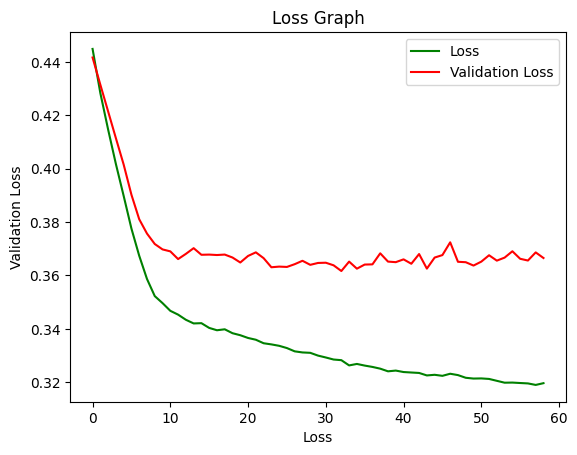

In [ ]:
plt.plot(training_info.history['loss'],color='green',label='Loss')
plt.plot(training_info.history['val_loss'],color='red',label='Validation Loss')
plt.title('Loss Graph')
plt.xlabel('Loss')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

In [ ]:
y_pred=model.predict(x_test)
y_pred=(y_pred>0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
y_test

,Exited
6252,0
4684,0
1731,0
4742,0
4521,0
...,...
6412,1
8285,0
7853,1
1095,1


In [ ]:
y_pred

array([[False],
       [False],
       [False],
       ...,
       [ True],
       [False],
       [False]])

In [ ]:
cm=confusion_matrix(y_test,y_pred)

In [ ]:
cm

array([[1526,   81],
       [ 206,  187]])

In [ ]:
score=accuracy_score(y_test,y_pred)

In [ ]:
score

0.8565